In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

df = pd.read_parquet(r"E:\EY\EY_Project\fact_object.parquet")
df.head()

,obj_id,biz_type,prod_ver,shop_tag,item_type,item_name,pay_method,pay_type,activate_type,pay_ts,...,m_2037_12,m_2038_01,m_2038_02,m_2038_03,m_2038_04,m_2038_05,m_2038_06,m_2038_07,m_2038_08,m_2038_09
0,000001,知识店铺,知识店铺旗舰版,其他,版本订单,专业版,线下汇款,支付,首开,2023/6/13 14:20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000002,知识店铺,知识店铺旗舰版,其他,版本订单,专业版,免费赠送,赠送,赠送-冲抵,2023/6/13 14:20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000003,知识店铺,知识店铺旗舰版,其他,版本订单,专业版,免费赠送,赠送,赠送-重算,2023/6/13 14:20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,000004,知识店铺,知识店铺旗舰版,其他,版本订单,专业版,线下转账（平安）,支付,续费,2024/10/16 19:11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,000005,知识店铺,知识店铺旗舰版,其他,版本订单,旗舰版,线上微信,升级,升级-冲抵,2024/12/10 10:46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.columns.tolist()

['obj_id',
 'biz_type',
 'prod_ver',
 'shop_tag',
 'item_type',
 'item_name',
 'pay_method',
 'pay_type',
 'activate_type',
 'pay_ts',
 'eff_ts',
 'exp0_ts',
 'exp_ts',
 'eff_date',
 'exp0_date',
 'exp_date',
 'pay_dt',
 'eff_dt',
 'exp0_dt',
 'exp_dt',
 'amt_alloc',
 'amt_used',
 'amt_rem',
 'amt_unalloc',
 'days_total',
 'mos_total',
 'amt_day_avg',
 'amt_day_avg_v2',
 'days_used',
 'm_sum',
 'm_nz_cnt',
 'm_span',
 'm_gap_cnt',
 'm_gap_rt',
 'res_m_sum_vs_amt',
 'rt_m_sum_to_amt',
 'res_amt_used_rem',
 'seg_grp',
 'svc_days',
 'svc_mos_apx',
 'resched_days',
 'pay2eff_days',
 'd_svc_days_vs_total',
 'd_svc_mos_vs_total',
 'f_amt_neg',
 'f_m_sum_neg',
 'f_svc_neg',
 'f_svc_gt_5y',
 'f_resched_gt_90d',
 'f_pay_after_eff',
 'abs_res_m_sum_vs_amt',
 'abs_res_amt_used_rem',
 'd_amort_mos_vs_svc',
 'abs_d_amort_mos_vs_svc',
 'f_amort_svc_mis_2m',
 'm_2017_02',
 'm_2017_03',
 'm_2017_04',
 'm_2017_05',
 'm_2017_06',
 'm_2017_07',
 'm_2017_08',
 'm_2017_09',
 'm_2017_10',
 'm_2017_11',
 'm_

In [4]:
required_cols = [
    # 分群相关
    "biz_type",
    "pay_type",
    "activate_type",

    # 分层 / 建模基准
    "seg_grp",

    # 对象标识
    "obj_id",
]

missing = [c for c in required_cols if c not in df.columns]
print("Missing columns:", missing if missing else "None")

Missing columns: None


In [5]:
GROUP_COLS = ["biz_type", "pay_type", "activate_type"]   # 你也可以只放一个，比如 ["业务类型"]

# 小样本阈值：低于该阈值的组，会被合并到 OTHER（通过逐层回退实现）
MIN_GROUP_SIZE = 500   # 常用 200 或 500

# OTHER 标签
OTHER_LABEL = "OTHER"

# （可选）segment_model 如果你已经有该字段，希望先在 segment_model 内部分群，就填上；没有就设为 None
SEGMENT_MODEL_COL = "seg_grp" if "seg_grp" in df.columns else None

In [6]:
def _clean_cat(s: pd.Series) -> pd.Series:
    # 保持字符串一致性，避免 " 企学院 "、空串、None 混在一起
    s = s.astype("string")
    s = s.str.strip()
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "NULL": pd.NA})
    s = s.fillna("UNKNOWN")
    return s

for c in GROUP_COLS:
    if c not in df.columns:
        raise KeyError(f"df 缺少分群字段：{c}。请检查字段名或先在 Notebook 1 里生成。")
    df[c] = _clean_cat(df[c])

if SEGMENT_MODEL_COL:
    df[SEGMENT_MODEL_COL] = _clean_cat(df[SEGMENT_MODEL_COL])

# Optional hygiene: remove hidden newlines / tabs in categorical columns
for c in ([SEGMENT_MODEL_COL] if SEGMENT_MODEL_COL else []) + GROUP_COLS:
    df[c] = df[c].astype("string").str.replace(r"[\r\n\t]+", " ", regex=True).str.strip()

In [7]:
cols = GROUP_COLS.copy()

# 分层优先：先在 segment_model 内部做回退合并（如果存在）
base_cols = ([SEGMENT_MODEL_COL] if SEGMENT_MODEL_COL else []) + cols

In [8]:
for k in range(len(cols)):
    gcols = base_cols  # 当前检查的分组维度（仍用全维度检查规模）
    group_size = df.groupby(gcols, dropna=False).size()
    small_groups = group_size[group_size < MIN_GROUP_SIZE].index

    if len(small_groups) == 0:
        break

    # 找到当前需要被 OTHER 化的维度：从最末维度开始逐层回退
    backoff_col = cols[-(k+1)]

    # 将 small_groups 对应的行 backoff_col 置为 OTHER
    # 为了高效：用 merge 标记小组
    small_df = pd.DataFrame(list(small_groups), columns=gcols)
    small_df["_is_small_group"] = 1

    df = df.merge(small_df, on=gcols, how="left")
    mask = df["_is_small_group"].fillna(0).astype(int) == 1
    df.loc[mask, backoff_col] = OTHER_LABEL
    df = df.drop(columns=["_is_small_group"])

In [9]:
key_cols = base_cols
df["group_key"] = df[key_cols].astype("string").agg("|".join, axis=1)

# 稳定映射：按字典序排序后编码，保证每次运行一致（只要 group_key 集合不变）
group_keys_sorted = np.sort(df["group_key"].unique())
group_id_map = {k: i for i, k in enumerate(group_keys_sorted, start=1)}  # 从 1 开始
df["group_id"] = df["group_key"].map(group_id_map).astype("int32")

In [10]:
print("=== Segmentation summary ===")
print("Rows:", len(df))
print("Groups:", df["group_id"].nunique())
print("Min group size:", df.groupby(key_cols).size().min())
print("Top 10 largest groups:")
display(df.groupby(key_cols).size().sort_values(ascending=False).head(10).to_frame("n"))

print("\nTop 10 smallest groups (post-backoff):")
display(df.groupby(key_cols).size().sort_values(ascending=True).head(10).to_frame("n"))

=== Segmentation summary ===
Rows: 726932
Groups: 25
Min group size: 58
Top 10 largest groups:


n
seg_grp        biz_type pay_type activate_type        
A1_model_core  知识店铺     支付       首开             232532
                                 续费             143012
B_offset_neg   知识店铺     赠送       赠送-冲抵           97857
A1_model_core  知识店铺     赠送       赠送-重算           97857
A0_zero_matrix 知识店铺     支付       资源              83847
B_offset_neg   知识店铺     升级       升级-冲抵           14582
A1_model_core  知识店铺     升级       升级-重算           14582
                        关服务      关服务-重算           7288
B_offset_neg   知识店铺     关服务      关服务-冲抵           7288
A1_model_core  企学院      支付       续费               6897


Top 10 smallest groups (post-backoff):


n
seg_grp        biz_type pay_type activate_type     
E_amt_zero     OTHER    OTHER    OTHER           58
B_offset_neg   OTHER    OTHER    OTHER          118
A0_zero_matrix OTHER    OTHER    OTHER          212
E_amt_zero     知识店铺     OTHER    OTHER          520
B_offset_neg   企学院      OTHER    OTHER          666
E_amt_zero     知识店铺     关服务      关服务-冲抵         697
                                 关服务-重算         697
A1_model_core  OTHER    OTHER    OTHER          720
               小鹅打卡店铺   支付       首开             835
               课程商城     支付       资源             939

In [12]:
# Cell 1.1 — Tail pooling fix (only for fully-backoff groups)

TAIL_SEG_LABEL = "TAIL_POOL"

if SEGMENT_MODEL_COL:
    key_cols = [SEGMENT_MODEL_COL] + GROUP_COLS

    # 找出已经完全回退到 OTHER 的行
    full_other_mask = True
    for c in GROUP_COLS:
        full_other_mask &= (df[c] == OTHER_LABEL)

    # 计算这些 "segment_model|OTHER|OTHER|OTHER" 的组规模
    tail_sizes = df.loc[full_other_mask].groupby([SEGMENT_MODEL_COL]).size()

    # 哪些 segment_model 的尾部池仍然 < 阈值，就跨 segment_model 合并
    small_tail_segs = tail_sizes[tail_sizes < MIN_GROUP_SIZE].index

    df.loc[full_other_mask & df[SEGMENT_MODEL_COL].isin(small_tail_segs), SEGMENT_MODEL_COL] = TAIL_SEG_LABEL

    # 重新生成 group_key / group_id（因为 segment_model 变了）
    key_cols = ([SEGMENT_MODEL_COL] if SEGMENT_MODEL_COL else []) + GROUP_COLS
    df["group_key"] = df[key_cols].astype("string").agg("|".join, axis=1)

    group_keys_sorted = np.sort(df["group_key"].unique())
    group_id_map = {k: i for i, k in enumerate(group_keys_sorted, start=1)}
    df["group_id"] = df["group_key"].map(group_id_map).astype("int32")

    # 复核
    print("After tail pooling:")
    print("Groups:", df["group_id"].nunique())
    print("Min group size:", df.groupby(key_cols).size().min())

After tail pooling:
Groups: 23
Min group size: 388


In [13]:
print("Top 10 largest groups:")
display(df.groupby(key_cols).size().sort_values(ascending=False).head(10).to_frame("n"))

print("\nTop 10 smallest groups (post-backoff):")
display(df.groupby(key_cols).size().sort_values(ascending=True).head(10).to_frame("n"))

Top 10 largest groups:


n
seg_grp        biz_type pay_type activate_type        
A1_model_core  知识店铺     支付       首开             232532
                                 续费             143012
B_offset_neg   知识店铺     赠送       赠送-冲抵           97857
A1_model_core  知识店铺     赠送       赠送-重算           97857
A0_zero_matrix 知识店铺     支付       资源              83847
A1_model_core  知识店铺     升级       升级-重算           14582
B_offset_neg   知识店铺     升级       升级-冲抵           14582
A1_model_core  知识店铺     关服务      关服务-重算           7288
B_offset_neg   知识店铺     关服务      关服务-冲抵           7288
A1_model_core  企学院      支付       续费               6897


Top 10 smallest groups (post-backoff):


n
seg_grp       biz_type pay_type activate_type      
TAIL_POOL     OTHER    OTHER    OTHER           388
E_amt_zero    知识店铺     OTHER    OTHER           520
B_offset_neg  企学院      OTHER    OTHER           666
E_amt_zero    知识店铺     关服务      关服务-冲抵          697
                                关服务-重算          697
A1_model_core OTHER    OTHER    OTHER           720
              小鹅打卡店铺   支付       首开              835
              课程商城     支付       资源              939
C_conflict    知识店铺     退款       资源             1132
B_offset_neg  知识店铺     退款       退款-有时长         1950

In [14]:
import re

month_cols = [c for c in df.columns if re.match(r"^m_\d{4}_\d{2}$", str(c))]

exclude_cols = set(GROUP_COLS + ["group_key", "group_id"])
if SEGMENT_MODEL_COL:
    exclude_cols.add(SEGMENT_MODEL_COL)

exclude_patterns = ("时间", "日期", "date", "time", "ts")
numeric_cols = []
for c in df.columns:
    if c in exclude_cols:
        continue
    if c in month_cols:
        continue
    if any(p in str(c) for p in exclude_patterns):
        continue
    if pd.api.types.is_numeric_dtype(df[c]):
        numeric_cols.append(c)

if len(numeric_cols) == 0:
    raise ValueError("未找到可用于 Robust Z 的数值列。请手动指定 numeric_cols 白名单。")

print(f"Robust Z features (n={len(numeric_cols)}):", numeric_cols[:])

Robust Z features (n=34): ['amt_alloc', 'amt_used', 'amt_rem', 'amt_unalloc', 'days_total', 'mos_total', 'amt_day_avg', 'amt_day_avg_v2', 'days_used', 'm_sum', 'm_nz_cnt', 'm_span', 'm_gap_cnt', 'm_gap_rt', 'res_m_sum_vs_amt', 'rt_m_sum_to_amt', 'res_amt_used_rem', 'svc_days', 'svc_mos_apx', 'resched_days', 'pay2eff_days', 'd_svc_days_vs_total', 'd_svc_mos_vs_total', 'f_amt_neg', 'f_m_sum_neg', 'f_svc_neg', 'f_svc_gt_5y', 'f_resched_gt_90d', 'f_pay_after_eff', 'abs_res_m_sum_vs_amt', 'abs_res_amt_used_rem', 'd_amort_mos_vs_svc', 'abs_d_amort_mos_vs_svc', 'f_amort_svc_mis_2m']


In [30]:
TOP_PCT_RZ = 0.01   # 组内 Top 1% 判为异常（你可改 0.005/0.02）
MAD_EPS = 1e-9
RZ_SCALE = 0.6745   # 使 MAD 在正态下与 std 可比

# median
med = df.groupby("group_id")[numeric_cols].transform("median")

# MAD = median(|x - median|)
abs_dev = (df[numeric_cols] - med).abs()
mad = abs_dev.groupby(df["group_id"]).transform("median").clip(lower=MAD_EPS)

# robust z
rz = (df[numeric_cols] - med) / mad * RZ_SCALE

# 聚合成单一分数：max(|rz|)
df["anomaly_score_rz"] = rz.abs().max(axis=1).astype("float32")

# 组内 Top X% 打标
df["rz_rank_pct_in_group"] = df.groupby("group_id")["anomaly_score_rz"].rank(pct=True, method="average")
df["is_anomaly_rz"] = (df["rz_rank_pct_in_group"] >= (1 - TOP_PCT_RZ)).astype("int8")

max_idx = rz.abs().to_numpy().argmax(axis=1)
df["rz_top_feature"] = np.array(numeric_cols, dtype=object)[max_idx]

print("=== Robust Z summary ===")
print("Rows:", len(df))
print("Flag rate (approx):", df["is_anomaly_rz"].mean())
display(df.groupby("group_id")["is_anomaly_rz"].mean().sort_values(ascending=False).head(5).to_frame("flag_rate"))

=== Robust Z summary ===
Rows: 726932
Flag rate (approx): 0.009585490802440944


,flag_rate
group_id,
16,0.018486
2,0.013889
23,0.012887
12,0.010650
13,0.010511


In [33]:
import re
import numpy as np
import pandas as pd

# ===== params =====
HAMPEL_W   = 5
HAMPEL_K   = 3.0
MIN_VALID  = 7
TOP_PCT_H  = 0.01
MAD_EPS    = 1e-6       # float32更稳一点
RZ_SCALE   = 0.6745

# ===== month cols =====
month_cols = [c for c in df.columns if re.match(r"^m_\d{4}_\d{2}$", str(c))]
month_cols = sorted(month_cols)
T = len(month_cols)
if T == 0:
    raise ValueError("No month columns found like m_YYYY_MM")

# ===== month index parse (fast & safe) =====
month_str = [c.replace("m_", "").replace("_", "-") + "-01" for c in month_cols]
month_index = pd.to_datetime(month_str, format="%Y-%m-%d", errors="raise")
m0_mid = int(month_index[0].year * 12 + (month_index[0].month - 1))

# ===== row window [start,end] =====
eff_dt = pd.to_datetime(df["eff_dt"], errors="coerce")
exp_dt = pd.to_datetime(df["exp_dt"], errors="coerce")

eff_mid = (eff_dt.dt.year * 12 + (eff_dt.dt.month - 1)).astype("float64").to_numpy()
exp_mid = (exp_dt.dt.year * 12 + (exp_dt.dt.month - 1)).astype("float64").to_numpy()

bad_date = (~np.isfinite(eff_mid)) | (~np.isfinite(exp_mid))
swap = (~bad_date) & (eff_mid > exp_mid)
tmp = eff_mid.copy()
eff_mid[swap] = exp_mid[swap]
exp_mid[swap] = tmp[swap]

start_idx = np.clip(eff_mid - m0_mid, 0, T-1)
end_idx   = np.clip(exp_mid - m0_mid, 0, T-1)
start_idx[bad_date] = 0
end_idx[bad_date]   = -1

start_idx = start_idx.astype(np.int32)
end_idx   = end_idx.astype(np.int32)
win_len = (end_idx - start_idx + 1).astype(np.int32)
win_len[win_len < 0] = 0

# ===== month matrix (float32) =====
X = df[month_cols].to_numpy(np.float32, copy=True)

# ===== count valid months within window =====
t = np.arange(T, dtype=np.int32)[None, :]
mask_win = (t >= start_idx[:, None]) & (t <= end_idx[:, None])
valid_mask = mask_win & (X != 0)
m_valid_cnt = valid_mask.sum(axis=1).astype(np.int16)

df["m_valid_cnt"] = m_valid_cnt
df["no_month_data"] = ((win_len == 0) | (m_valid_cnt == 0)).astype(np.int8)
df["short_window"]  = ((m_valid_cnt > 0) & (m_valid_cnt < MIN_VALID)).astype(np.int8)

# ===== only compute hampel for applicable rows =====
valid_rt = (m_valid_cnt.astype(np.float32) / np.maximum(win_len, 1)).astype(np.float32)
app = (m_valid_cnt >= 9) & (win_len >= 12) & (valid_rt >= 0.6)
app_idx = np.where(app)[0].astype(np.int32)

print("Applicable rows:", app_idx.size, "/", len(df), "(", app_idx.size/len(df), ")")

# ===== numba hampel (rolling median/MAD with small window) =====
from numba import njit
import numpy as np

@njit
def _median_small(a):
    b = a.copy()
    b.sort()
    n = b.size
    mid = n // 2
    if n % 2 == 1:
        return b[mid]
    else:
        return 0.5 * (b[mid-1] + b[mid])

@njit
def hampel_row_ignore_zero(x, start, end, W, K, mad_eps, rz_scale):
    score = -1.0
    out_cnt = 0
    top_j = -1

    for j in range(start, end+1):
        lo = j - W
        hi = j + W
        if lo < start: lo = start
        if hi > end:   hi = end

        # collect NON-ZERO window values
        # upper bound length = 2W+1, allocate fixed then slice
        buf = np.empty((hi - lo + 1), dtype=np.float32)
        k = 0
        for t in range(lo, hi+1):
            v = x[t]
            if v != 0.0 and not np.isnan(v):
                buf[k] = v
                k += 1

        # too few points => skip
        if k < 3:
            continue

        buf2 = buf[:k]
        med = _median_small(buf2)

        dev = np.empty(k, dtype=np.float32)
        for u in range(k):
            dev[u] = abs(buf2[u] - med)

        mad = _median_small(dev)
        if mad < mad_eps:
            mad = mad_eps

        # evaluate this month value (if current month is zero => skip)
        if x[j] == 0.0 or np.isnan(x[j]):
            continue

        hz = (x[j] - med) / mad * rz_scale
        ahz = abs(hz)

        if ahz > score:
            score = ahz
            top_j = j
        if ahz > K:
            out_cnt += 1

    if score < 0:
        return np.nan, 0, -1
    return score, out_cnt, top_j

@njit
def hampel_batch_ignore_zero(X, start_idx, end_idx, rows, W, K, mad_eps, rz_scale):
    n = rows.size
    score = np.empty(n, dtype=np.float32)
    out_cnt = np.empty(n, dtype=np.int16)
    top_j = np.empty(n, dtype=np.int16)
    for i in range(n):
        r = rows[i]
        sc, oc, tj = hampel_row_ignore_zero(X[r], start_idx[r], end_idx[r], W, K, mad_eps, rz_scale)
        score[i] = sc
        out_cnt[i] = oc
        top_j[i] = tj
    return score, out_cnt, top_j

# run
h_score, h_out_cnt, h_top_j = hampel_batch_ignore_zero(
    X, start_idx, end_idx, app_idx, HAMPEL_W, HAMPEL_K, MAD_EPS, RZ_SCALE
)


# write back
df["hampel_score"] = np.nan
df["hampel_out_cnt"] = 0
df["hampel_top_month"] = None
ok = (h_top_j >= 0)
df.loc[app_idx[ok], "hampel_top_month"] = np.array(month_cols, dtype=object)[h_top_j[ok]]
df["hampel_applicable"] = app.astype(np.int8)

df.loc[app_idx, "hampel_score"] = h_score
df.loc[app_idx, "hampel_out_cnt"] = h_out_cnt
df.loc[app_idx, "hampel_top_month"] = np.array(month_cols, dtype=object)[h_top_j]

# outlier rate
den = np.maximum(df["m_valid_cnt"].astype(np.int32), 1)
df["hampel_out_rt"] = (df["hampel_out_cnt"].astype(np.float32) / den).astype(np.float32)

# ===== group-wise ranking among applicable =====
df["h_rank_pct_in_group"] = np.nan
tmp = df.loc[df["hampel_applicable"] == 1, ["group_id", "hampel_score"]].copy()
tmp["h_rank_pct_in_group"] = tmp.groupby("group_id")["hampel_score"].rank(pct=True, method="average")
df.loc[tmp.index, "h_rank_pct_in_group"] = tmp["h_rank_pct_in_group"].astype(np.float32)

df["is_anomaly_h"] = 0
mask_flag = (df["hampel_applicable"] == 1) & df["h_rank_pct_in_group"].notna()
df.loc[mask_flag, "is_anomaly_h"] = (
    df.loc[mask_flag, "h_rank_pct_in_group"] >= (1 - TOP_PCT_H)
).astype(np.int8)

print("=== Hampel summary (Numba, gated) ===")
print("Rows:", len(df))
print("Applicable rate:", float(df["hampel_applicable"].mean()))
print("Flag rate:", float(df["is_anomaly_h"].mean()))
print("No-month-data rate:", float(df["no_month_data"].mean()))
print("Short-window rate:", float(df["short_window"].mean()))

Applicable rows: 557973 / 726932 ( 0.7675724827081488 )
=== Hampel summary (Numba, gated) ===
Rows: 726932
Applicable rate: 0.7675724827081488
Flag rate: 0.008502858589249063
No-month-data rate: 0.11986815823213175
Short-window rate: 0.07471262786615529


In [38]:
import re
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

# =========================
# 0) Feature whitelist (EN columns you provided)
# =========================
X_cols = [
    # amounts / durations / averages
    "amt_alloc", "amt_used", "amt_rem", "amt_unalloc",
    "days_total", "mos_total", "days_used",
    "amt_day_avg", "amt_day_avg_v2",

    # monthly summary features
    "m_sum", "m_nz_cnt", "m_span", "m_gap_cnt", "m_gap_rt",

    # ratio / residual features
    "rt_m_sum_to_amt", "res_m_sum_vs_amt", "abs_res_m_sum_vs_amt",
    "res_amt_used_rem", "abs_res_amt_used_rem",
    "resched_days", "pay2eff_days",
    "svc_days", "svc_mos_apx",
    "d_svc_days_vs_total", "d_svc_mos_vs_total",
    "d_amort_mos_vs_svc", "abs_d_amort_mos_vs_svc",

    # optional flags: keep if you want (they are features, not labels)
    # if you don't want binary flags in IF/LOF, comment these out
    "f_amt_neg", "f_m_sum_neg", "f_svc_neg", "f_svc_gt_5y",
    "f_resched_gt_90d", "f_pay_after_eff",
    "f_amort_svc_mis_2m",
]

# 1) Column existence check
missing = [c for c in X_cols if c not in df.columns]
if missing:
    raise KeyError(f"这些特征列在 df 里不存在：{missing}")

# 2) Ensure numeric dtype (coerce object -> numeric where possible)
#    (safe for IF/LOF; non-parsable becomes NaN and later imputed)
df[X_cols] = df[X_cols].apply(pd.to_numeric, errors="coerce")

print("X_cols ready:", len(X_cols))

# =========================
# helper: diagnose
# =========================
def col_diagnose(df, cols):
    tmp = df[cols].replace([np.inf, -np.inf], np.nan)
    # only numeric for stats
    num = tmp.select_dtypes(include=[np.number])
    diag = pd.DataFrame({
        "na_cnt": tmp.isna().sum(),
        "na_pct": tmp.isna().mean(),
        "nunique": tmp.nunique(dropna=True),
        "min": num.min(),
        "p01": num.quantile(0.01),
        "p50": num.quantile(0.50),
        "p99": num.quantile(0.99),
        "max": num.max(),
    }).sort_values(["na_pct", "nunique"], ascending=[False, True])
    return diag

display(col_diagnose(df, X_cols).round(3))

# =========================
# Step 1: drop constant / near-constant columns
# =========================
# nunique <= 1 -> constant
nunique = df[X_cols].nunique(dropna=True)
const_cols = nunique[nunique <= 1].index.tolist()

# optional: near-constant (e.g. >99.5% same value) -> drop
# (comment out if你不想这么激进)
# top_share = df[X_cols].apply(lambda s: s.value_counts(dropna=True, normalize=True).iloc[0] if s.notna().any() else 1.0)
# near_const_cols = top_share[top_share >= 0.995].index.tolist()
# const_cols = sorted(set(const_cols + near_const_cols))

if const_cols:
    print("Dropping constant/near-constant cols:", const_cols)
    X_cols = [c for c in X_cols if c not in const_cols]

print("X_cols after drop:", len(X_cols))

# =========================
# Step 2: set negative values -> NaN for non-negative columns
# =========================
nonneg_cols = [
    "svc_days", "svc_mos_apx",
    "pay2eff_days", "resched_days",
    "days_total", "mos_total", "days_used",
    "m_span", "m_nz_cnt", "m_gap_cnt", "m_gap_rt",
]
nonneg_cols = [c for c in nonneg_cols if c in X_cols]

for c in nonneg_cols:
    neg_cnt = int((df[c] < 0).sum(skipna=True))
    if neg_cnt > 0:
        print(f"{c}: negative -> NaN count = {neg_cnt}")
        df.loc[df[c] < 0, c] = np.nan

# =========================
# Step 3: winsorize / clip heavy-tail continuous columns
# =========================
clip_cols = [
    "resched_days", "pay2eff_days",
    "d_svc_days_vs_total", "d_svc_mos_vs_total",
    "d_amort_mos_vs_svc", "abs_d_amort_mos_vs_svc",
    "svc_days", "svc_mos_apx",
    "amt_alloc", "amt_used", "amt_rem", "amt_unalloc",
    "amt_day_avg", "amt_day_avg_v2",
    "m_sum",
    "rt_m_sum_to_amt", "res_m_sum_vs_amt", "abs_res_m_sum_vs_amt",
    "res_amt_used_rem", "abs_res_amt_used_rem",
]
clip_cols = [c for c in clip_cols if c in X_cols]

def winsorize_df(df, cols, ql=0.01, qh=0.99):
    for c in cols:
        s = df[c].replace([np.inf, -np.inf], np.nan)
        if s.notna().sum() == 0:
            continue
        lo = s.quantile(ql)
        hi = s.quantile(qh)
        df[c] = s.clip(lo, hi)
    return df

df = winsorize_df(df, clip_cols, ql=0.01, qh=0.99)
print("winsorize done:", clip_cols)

# =========================
# Step 4: fill NaN with global median (robust for IF/LOF)
# =========================
df[X_cols] = df[X_cols].replace([np.inf, -np.inf], np.nan)
med = df[X_cols].median(numeric_only=True)
df[X_cols] = df[X_cols].fillna(med)

print("NaN fill done.")

display(col_diagnose(df, X_cols).round(3))

print("Final X_cols:", len(X_cols))
print(X_cols)

X_cols ready: 34


,na_cnt,na_pct,nunique,min,p01,p50,p99,max
m_gap_cnt,0,0.0,1,0.000,0.000,0.000,0.000,0.000
m_gap_rt,0,0.0,1,0.000,0.000,0.000,0.000,0.000
f_amt_neg,0,0.0,2,0.000,0.000,0.000,1.000,1.000
f_m_sum_neg,0,0.0,2,0.000,0.000,0.000,1.000,1.000
f_svc_neg,0,0.0,2,0.000,0.000,0.000,0.000,1.000
f_svc_gt_5y,0,0.0,2,0.000,0.000,0.000,0.000,1.000
f_resched_gt_90d,0,0.0,2,0.000,0.000,0.000,1.000,1.000
f_pay_after_eff,0,0.0,2,0.000,0.000,0.000,0.000,1.000
f_amort_svc_mis_2m,0,0.0,2,0.000,0.000,0.000,0.000,1.000
rt_m_sum_to_amt,0,0.0,18,0.000,0.000,1.000,1.000,1.000


Dropping constant/near-constant cols: ['m_gap_cnt', 'm_gap_rt']
X_cols after drop: 32
winsorize done: ['resched_days', 'pay2eff_days', 'd_svc_days_vs_total', 'd_svc_mos_vs_total', 'd_amort_mos_vs_svc', 'abs_d_amort_mos_vs_svc', 'svc_days', 'svc_mos_apx', 'amt_alloc', 'amt_used', 'amt_rem', 'amt_unalloc', 'amt_day_avg', 'amt_day_avg_v2', 'm_sum', 'rt_m_sum_to_amt', 'res_m_sum_vs_amt', 'abs_res_m_sum_vs_amt', 'res_amt_used_rem', 'abs_res_amt_used_rem']
NaN fill done.


,na_cnt,na_pct,nunique,min,p01,p50,p99,max
f_amt_neg,0,0.0,2,0.000,0.000,0.000,1.000,1.000
f_m_sum_neg,0,0.0,2,0.000,0.000,0.000,1.000,1.000
f_svc_neg,0,0.0,2,0.000,0.000,0.000,0.000,1.000
f_svc_gt_5y,0,0.0,2,0.000,0.000,0.000,0.000,1.000
f_resched_gt_90d,0,0.0,2,0.000,0.000,0.000,1.000,1.000
f_pay_after_eff,0,0.0,2,0.000,0.000,0.000,0.000,1.000
f_amort_svc_mis_2m,0,0.0,2,0.000,0.000,0.000,0.000,1.000
rt_m_sum_to_amt,0,0.0,18,0.000,0.000,1.000,1.000,1.000
m_nz_cnt,0,0.0,95,0.000,0.000,13.000,37.000,239.000
m_span,0,0.0,95,0.000,0.000,13.000,37.000,239.000


Final X_cols: 32
['amt_alloc', 'amt_used', 'amt_rem', 'amt_unalloc', 'days_total', 'mos_total', 'days_used', 'amt_day_avg', 'amt_day_avg_v2', 'm_sum', 'm_nz_cnt', 'm_span', 'rt_m_sum_to_amt', 'res_m_sum_vs_amt', 'abs_res_m_sum_vs_amt', 'res_amt_used_rem', 'abs_res_amt_used_rem', 'resched_days', 'pay2eff_days', 'svc_days', 'svc_mos_apx', 'd_svc_days_vs_total', 'd_svc_mos_vs_total', 'd_amort_mos_vs_svc', 'abs_d_amort_mos_vs_svc', 'f_amt_neg', 'f_m_sum_neg', 'f_svc_neg', 'f_svc_gt_5y', 'f_resched_gt_90d', 'f_pay_after_eff', 'f_amort_svc_mis_2m']


In [39]:
TOP_PCT_IF = 0.01
IF_PARAMS = dict(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

df["anomaly_score_if"] = np.nan

for gid, g in df.groupby("group_id", sort=False):
    idx = g.index
    Xg = g[X_cols].copy()

    # 组内兜底：再填一次中位数，防止某组某列全缺导致 median=NaN
    Xg = Xg.replace([np.inf, -np.inf], np.nan)
    Xg = Xg.fillna(Xg.median(numeric_only=True))
    Xg = Xg.fillna(0.0)

    scaler = RobustScaler()
    Xs = scaler.fit_transform(Xg)

    model = IsolationForest(**IF_PARAMS)
    model.fit(Xs)

    # 统一成“越大越异常”
    df.loc[idx, "anomaly_score_if"] = -model.score_samples(Xs)

df["if_rank_pct_in_group"] = df.groupby("group_id")["anomaly_score_if"].rank(pct=True, method="average")
df["is_anomaly_if"] = (df["if_rank_pct_in_group"] >= (1 - TOP_PCT_IF)).astype("int8")

print("IF done. is_anomaly_if rate =", float(df["is_anomaly_if"].mean()))

IF done. is_anomaly_if rate = 0.0097175526734275


In [40]:
TOP_PCT_LOF = 0.01
BASE_N_NEIGHBORS = 20

df["anomaly_score_lof"] = np.nan

for gid, g in df.groupby("group_id", sort=False):
    idx = g.index
    n = len(g)

    if n < 10:
        df.loc[idx, "anomaly_score_lof"] = 0.0
        continue

    k = min(BASE_N_NEIGHBORS, n - 1)

    Xg = g[X_cols].copy()
    Xg = Xg.replace([np.inf, -np.inf], np.nan)
    Xg = Xg.fillna(Xg.median(numeric_only=True))
    Xg = Xg.fillna(0.0)

    scaler = RobustScaler()
    Xs = scaler.fit_transform(Xg)

    lof = LocalOutlierFactor(n_neighbors=k)
    lof.fit_predict(Xs)

    # 统一成“越大越异常”
    df.loc[idx, "anomaly_score_lof"] = -lof.negative_outlier_factor_

df["lof_rank_pct_in_group"] = df.groupby("group_id")["anomaly_score_lof"].rank(pct=True, method="average")
df["is_anomaly_lof"] = (df["lof_rank_pct_in_group"] >= (1 - TOP_PCT_LOF)).astype("int8")

print("LOF done. is_anomaly_lof rate =", float(df["is_anomaly_lof"].mean()))

LOF done. is_anomaly_lof rate = 0.01000506237172115


In [41]:
import numpy as np
import pandas as pd

# =========================
# 0) ranks: ensure float32
# =========================
df["rank_rz"]  = df["rz_rank_pct_in_group"].astype("float32")
df["rank_if"]  = df["if_rank_pct_in_group"].astype("float32")
df["rank_lof"] = df["lof_rank_pct_in_group"].astype("float32")

# Hampel ranks (if exist)
has_hampel = ("h_rank_pct_in_group" in df.columns) or ("hampel_rank_pct_in_group" in df.columns)
if "h_rank_pct_in_group" in df.columns:
    df["rank_h"] = df["h_rank_pct_in_group"].astype("float32")
elif "hampel_rank_pct_in_group" in df.columns:
    df["rank_h"] = df["hampel_rank_pct_in_group"].astype("float32")
else:
    df["rank_h"] = np.nan

# Hampel applicability (if exist)
if "hampel_applicable" in df.columns:
    df["h_app"] = df["hampel_applicable"].fillna(0).astype("int8")
else:
    df["h_app"] = 0

# =========================
# 1) business weights (tunable)
# =========================
# baseline weights: IF/LOF > Hampel > RZ
W_RZ  = 0.20
W_IF  = 0.35
W_LOF = 0.30
W_H   = 0.15

# if hampel not applicable => redistribute its weight to IF/LOF (more stable)
# (you can choose redistribute to all three, here I push to IF/LOF)
w_rz  = np.full(len(df), W_RZ,  dtype=np.float32)
w_if  = np.full(len(df), W_IF,  dtype=np.float32)
w_lof = np.full(len(df), W_LOF, dtype=np.float32)
w_h   = np.full(len(df), W_H,   dtype=np.float32)

mask_h_off = (df["h_app"] != 1) | (~np.isfinite(df["rank_h"].to_numpy()))
if mask_h_off.any():
    # redistribute W_H proportionally to IF & LOF
    add_if  = W_H * (W_IF / (W_IF + W_LOF))
    add_lof = W_H * (W_LOF / (W_IF + W_LOF))
    w_if[mask_h_off]  += add_if
    w_lof[mask_h_off] += add_lof
    w_h[mask_h_off]    = 0.0

# final normalize (safety)
w_sum = w_rz + w_if + w_lof + w_h
w_rz  = w_rz / w_sum
w_if  = w_if / w_sum
w_lof = w_lof / w_sum
w_h   = w_h / w_sum

# =========================
# 2) risk_score: weighted rank-ensemble
# =========================
# NOTE: rank_* should already be in [0,1] (pct rank); higher => more anomalous
r_rz  = df["rank_rz"].to_numpy(np.float32)
r_if  = df["rank_if"].to_numpy(np.float32)
r_lof = df["rank_lof"].to_numpy(np.float32)
r_h   = df["rank_h"].to_numpy(np.float32)

# nan-safe: if any of rz/if/lof is nan, fill with 0 (or group median) to avoid crashing
# (normally shouldn't happen if你前面rank都算对了)
r_rz  = np.nan_to_num(r_rz,  nan=0.0)
r_if  = np.nan_to_num(r_if,  nan=0.0)
r_lof = np.nan_to_num(r_lof, nan=0.0)
r_h   = np.nan_to_num(r_h,   nan=0.0)

df["risk_score"] = (w_rz*r_rz + w_if*r_if + w_lof*r_lof + w_h*r_h).astype("float32")

# =========================
# 3) ranks
# =========================
# object_id 可能是 obj_id；你这儿 out_cols 里用 object_id，会 miss
# 统一成 obj_id（优先 obj_id，否则 object_id）
ID_COL = "obj_id" if "obj_id" in df.columns else ("object_id" if "object_id" in df.columns else None)
if ID_COL is None:
    raise KeyError("df 中找不到 obj_id / object_id。请确认 ID 字段名。")

df["group_rank"]  = df.groupby("group_id")["risk_score"].rank(ascending=False, method="first").astype("int32")
df["global_rank"] = df["risk_score"].rank(ascending=False, method="first").astype("int32")
df["group_n"]     = df.groupby("group_id")[ID_COL].transform("size").astype("int32")

# =========================
# 4) output columns (EN schema)
# =========================
# 你现在字段是英文缩写版，所以这里按你英文列名来取；
# 若你还保留中文列，也会自动跳过不存在的列。

out_cols = []
for c in [
    # group meta
    "biz_type","pay_type","activate_type","group_key","group_id","group_n",ID_COL,
    # raw scores
    "anomaly_score_rz","anomaly_score_if","anomaly_score_lof",
    "hampel_score",
    # pct ranks
    "rank_rz","rank_if","rank_lof","rank_h",
    # weights (optional, good for debug/explain)
    # "w_rz","w_if","w_lof","w_h",  # <- 如果你想输出权重，把下面四列先写入df
    # ensemble
    "risk_score","group_rank","global_rank",
    # flags
    "is_anomaly_rz","is_anomaly_if","is_anomaly_lof","is_anomaly_h",
    # explain
    "rz_top_feature","hampel_top_month","m_valid_cnt","h_app"
]:
    if c in df.columns:
        out_cols.append(c)

# 如果你想把权重也输出（用于解释），把它们写回 df 再加入 out_cols
df["w_rz"]  = w_rz.astype("float32")
df["w_if"]  = w_if.astype("float32")
df["w_lof"] = w_lof.astype("float32")
df["w_h"]   = w_h.astype("float32")
for c in ["w_rz","w_if","w_lof","w_h"]:
    if c not in out_cols:
        out_cols.append(c)

out = df[out_cols].sort_values("global_rank").reset_index(drop=True)
display(out.head(20))

print("Weights (baseline):", {"rz":W_RZ, "if":W_IF, "lof":W_LOF, "h":W_H})
print("Hampel applicable rate:", float((df["h_app"]==1).mean()) if "h_app" in df.columns else None)
print("Top20 avg weights:", out[["w_rz","w_if","w_lof","w_h"]].head(20).mean().to_dict())

,biz_type,pay_type,activate_type,group_key,group_id,group_n,obj_id,anomaly_score_rz,anomaly_score_if,anomaly_score_lof,...,is_anomaly_lof,is_anomaly_h,rz_top_feature,hampel_top_month,m_valid_cnt,h_app,w_rz,w_if,w_lof,w_h
0,知识店铺,OTHER,OTHER,E_amt_zero|知识店铺|OTHER|OTHER,20,520,664075,3.844650e+10,0.694138,1.128469e+02,...,1,0,mos_total,None,0,0,0.2,0.430769,0.369231,0.00
1,知识店铺,支付,首开,A1_model_core|知识店铺|支付|首开,10,232532,121672,4.923850e+11,0.741153,3.308817e+10,...,1,1,days_total,m_2026_02,37,1,0.2,0.350000,0.300000,0.15
2,知识店铺,支付,首开,A1_model_core|知识店铺|支付|首开,10,232532,225732,7.513930e+11,0.773356,3.384341e+12,...,1,0,days_total,m_2025_02,49,1,0.2,0.350000,0.300000,0.15
3,知识店铺,支付,首开,A1_model_core|知识店铺|支付|首开,10,232532,451629,4.923850e+11,0.764154,1.862483e+10,...,1,1,days_total,m_2022_02,36,1,0.2,0.350000,0.300000,0.15
4,知识店铺,支付,首开,A1_model_core|知识店铺|支付|首开,10,232532,495015,4.923850e+11,0.764154,1.862483e+10,...,1,1,days_total,m_2023_02,37,1,0.2,0.350000,0.300000,0.15
5,知识店铺,支付,首开,A1_model_core|知识店铺|支付|首开,10,232532,510813,4.923850e+11,0.764154,1.862483e+10,...,1,1,days_total,m_2022_02,36,1,0.2,0.350000,0.300000,0.15
6,知识店铺,支付,首开,A1_model_core|知识店铺|支付|首开,10,232532,591792,4.923850e+11,0.764154,1.862483e+10,...,1,1,days_total,m_2023_02,36,1,0.2,0.350000,0.300000,0.15
7,知识店铺,支付,首开,A1_model_core|知识店铺|支付|首开,10,232532,423960,4.923850e+11,0.761598,1.259792e+10,...,1,1,days_total,m_2023_02,37,1,0.2,0.350000,0.300000,0.15
8,知识店铺,支付,首开,A1_model_core|知识店铺|支付|首开,10,232532,288539,4.923850e+11,0.762113,1.204469e+10,...,1,1,days_total,m_2023_02,37,1,0.2,0.350000,0.300000,0.15
9,知识店铺,支付,首开,A1_model_core|知识店铺|支付|首开,10,232532,537205,4.923850e+11,0.762113,1.201844e+10,...,1,1,days_total,m_2023_02,37,1,0.2,0.350000,0.300000,0.15


Weights (baseline): {'rz': 0.2, 'if': 0.35, 'lof': 0.3, 'h': 0.15}
Hampel applicable rate: 0.7675724827081488
Top20 avg weights: {'w_rz': 0.20000000298023224, 'w_if': 0.35403841733932495, 'w_lof': 0.30346161127090454, 'w_h': 0.14250001311302185}


In [43]:
topN = out.head(300)

print("Top300 group_id share:")
display(topN["group_id"].value_counts().head(10))

if "rz_top_feature" in topN.columns:
    print("Top300 rz_top_feature share:")
    display(topN["rz_top_feature"].value_counts().head(10))

print("Top300 label rates:")
print("RZ:", topN["is_anomaly_rz"].mean())
print("IF:", topN["is_anomaly_if"].mean())
print("LOF:", topN["is_anomaly_lof"].mean())
print("HAM:", topN["is_anomaly_h"].mean())

Top300 group_id share:


group_id
10    248
9      31
20      9
15      5
11      3
3       2
17      1
21      1
Name: count, dtype: int64

Top300 rz_top_feature share:


rz_top_feature
days_total          244
amt_alloc            31
mos_total             9
svc_days              5
resched_days          5
res_amt_used_rem      3
pay2eff_days          2
amt_rem               1
Name: count, dtype: int64

Top300 label rates:
RZ: 0.6
IF: 0.9833333333333333
LOF: 0.6333333333333333
HAM: 0.3566666666666667


In [44]:
import numpy as np
import pandas as pd

FLAG_COLS = {
    "RZ":  "is_anomaly_rz",
    "IF":  "is_anomaly_if",
    "LOF": "is_anomaly_lof",
    "HAM": "is_anomaly_h",
}

def overlap_tables(df_in, flag_cols=FLAG_COLS, index_col=None, topn=None):
    """
    返回三张表：
    - overlap_cnt: 两两同时命中数量
    - overlap_jacc: 两两Jaccard相似度
    - overlap_pbgivena: 条件概率 P(B|A)
    另外返回：
    - summary: 每个方法命中数/命中率
    - combo_dist: 4方法组合分布（例如 IF&LOF only / all four 等）
    """
    df = df_in.copy()

    # optional: restrict to topn (by global_rank or risk_score)
    if topn is not None:
        if index_col is None:
            # 默认按 global_rank (越小越靠前)，如果没有就按 risk_score (越大越靠前)
            if "global_rank" in df.columns:
                df = df.nsmallest(topn, "global_rank")
            elif "risk_score" in df.columns:
                df = df.nlargest(topn, "risk_score")
            else:
                raise KeyError("topn 已给，但 df 里没有 global_rank 或 risk_score；请传 index_col。")
        else:
            # index_col 若是排名字段（小=靠前）还是分数字段（大=靠前）你自己保证
            # 这里做一个自动判断：如果列名含 rank 则小优先，否则大优先
            if "rank" in index_col.lower():
                df = df.nsmallest(topn, index_col)
            else:
                df = df.nlargest(topn, index_col)

    # build boolean matrix
    M = pd.DataFrame({k: df[v].fillna(0).astype(int).astype(bool) for k, v in flag_cols.items()})
    methods = list(M.columns)
    n = len(M)

    # summary
    summary = pd.DataFrame({
        "hit_cnt": M.sum(axis=0).astype(int),
        "hit_rate": (M.mean(axis=0)).astype(float),
    }).sort_values("hit_cnt", ascending=False)

    # overlap count: |A ∩ B|
    overlap_cnt = pd.DataFrame(index=methods, columns=methods, dtype=int)
    for a in methods:
        for b in methods:
            overlap_cnt.loc[a, b] = int((M[a] & M[b]).sum())

    # jaccard: |A∩B| / |A∪B|
    overlap_jacc = pd.DataFrame(index=methods, columns=methods, dtype=float)
    for a in methods:
        for b in methods:
            inter = (M[a] & M[b]).sum()
            union = (M[a] | M[b]).sum()
            overlap_jacc.loc[a, b] = float(inter / union) if union > 0 else np.nan

    # conditional: P(B|A) = |A∩B| / |A|
    overlap_pbgivena = pd.DataFrame(index=methods, columns=methods, dtype=float)
    for a in methods:
        denom = M[a].sum()
        for b in methods:
            inter = (M[a] & M[b]).sum()
            overlap_pbgivena.loc[a, b] = float(inter / denom) if denom > 0 else np.nan

    # combo distribution (4-way)
    # 用 bit mask 编码：RZ=1, IF=2, LOF=4, HAM=8
    bit = {"RZ":1, "IF":2, "LOF":4, "HAM":8}
    code = np.zeros(n, dtype=int)
    for k in methods:
        code += M[k].to_numpy().astype(int) * bit[k]

    combo_dist = (
        pd.Series(code)
        .value_counts()
        .rename_axis("combo_code")
        .to_frame("cnt")
        .assign(rate=lambda x: x["cnt"]/n)
        .sort_values("cnt", ascending=False)
    )

    # decode helper
    def decode(c):
        parts = [k for k, b in bit.items() if (c & b) != 0]
        return "&".join(parts) if parts else "NONE"

    combo_dist["combo"] = [decode(c) for c in combo_dist.index]
    combo_dist = combo_dist[["combo","cnt","rate"]]

    return overlap_cnt, overlap_jacc, overlap_pbgivena, summary, combo_dist, M

# ====== 全量 overlap ======
overlap_cnt, overlap_jacc, overlap_pbgivena, summary, combo_dist, M = overlap_tables(df)

print("=== Summary (all rows) ===")
display(summary)

print("=== Overlap count |A∩B| ===")
display(overlap_cnt)

print("=== Jaccard similarity ===")
display(overlap_jacc.round(3))

print("=== Conditional P(B|A) ===")
display(overlap_pbgivena.round(3))

print("=== 4-way combo distribution ===")
display(combo_dist.head(12))

# ====== Top300 overlap（按 global_rank 优先）======
overlap_cnt_300, overlap_jacc_300, overlap_pbgivena_300, summary_300, combo_dist_300, M300 = overlap_tables(df, topn=300)

print("=== Summary (Top300) ===")
display(summary_300)

print("=== Overlap count (Top300) ===")
display(overlap_cnt_300)

print("=== Jaccard (Top300) ===")
display(overlap_jacc_300.round(3))

print("=== P(B|A) (Top300) ===")
display(overlap_pbgivena_300.round(3))

print("=== Combo dist (Top300) ===")
display(combo_dist_300.head(12))

=== Summary (all rows) ===


,hit_cnt,hit_rate
LOF,7273,0.010005
IF,7064,0.009718
RZ,6968,0.009585
HAM,6181,0.008503


=== Overlap count |A∩B| ===


,RZ,IF,LOF,HAM
RZ,6968.0,2415.0,157.0,368.0
IF,2415.0,7064.0,366.0,780.0
LOF,157.0,366.0,7273.0,192.0
HAM,368.0,780.0,192.0,6181.0


=== Jaccard similarity ===


...

,RZ,IF,LOF,HAM
RZ,1.000,0.599,0.317,0.287
IF,0.599,1.000,0.617,0.363
LOF,0.317,0.617,1.000,0.320
HAM,0.287,0.363,0.320,1.000


=== P(B|A) (Top300) ===


,RZ,IF,LOF,HAM
RZ,1.000,0.989,0.494,0.356
IF,0.603,1.000,0.627,0.363
LOF,0.468,0.974,1.000,0.379
HAM,0.598,1.000,0.673,1.000


=== Combo dist (Top300) ===


,combo,cnt,rate
combo_code,,,
3,RZ&IF,60,0.200000
6,IF&LOF,59,0.196667
7,RZ&IF&LOF,54,0.180000
14,IF&LOF&HAM,39,0.130000
15,RZ&IF&LOF&HAM,33,0.110000
11,RZ&IF&HAM,31,0.103333
2,IF,15,0.050000
10,IF&HAM,4,0.013333
4,LOF,3,0.010000


In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

topN = 300
top = out.head(topN).copy()

print("out shape:", out.shape, "top shape:", top.shape)

out shape: (726932, 30) top shape: (300, 30)


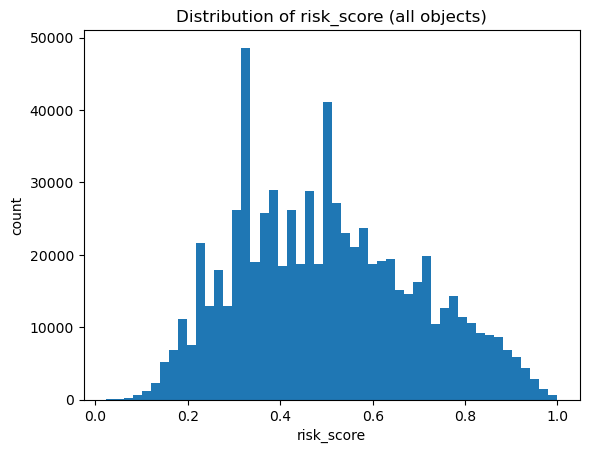

In [49]:
plt.figure()
plt.hist(out["risk_score"].values, bins=50)
plt.xlabel("risk_score")
plt.ylabel("count")
plt.title("Distribution of risk_score (all objects)")
plt.show()

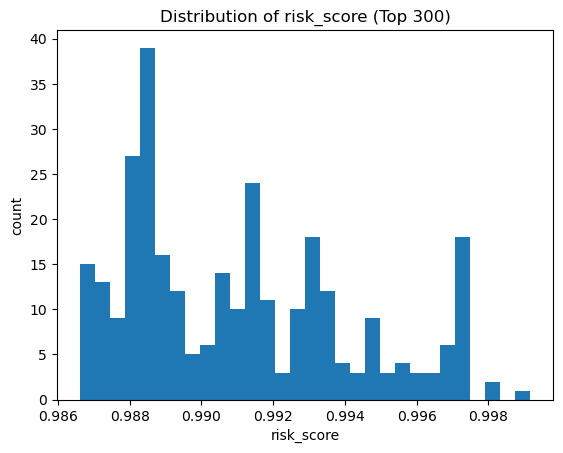

In [50]:
plt.figure()
plt.hist(top["risk_score"].values, bins=30)
plt.xlabel("risk_score")
plt.ylabel("count")
plt.title(f"Distribution of risk_score (Top {topN})")
plt.show()

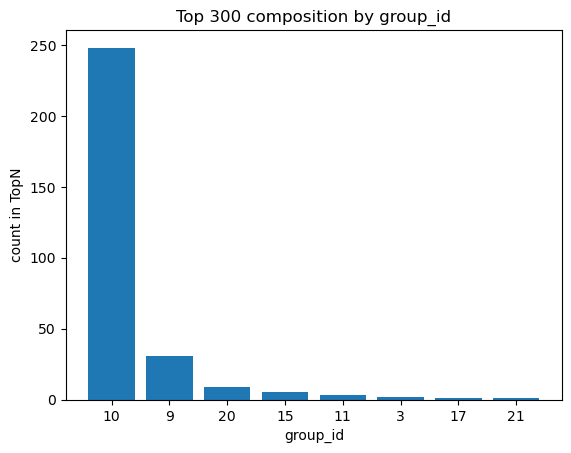

In [51]:
vc = top["group_id"].value_counts().sort_values(ascending=False)

plt.figure()
plt.bar(vc.index.astype(str), vc.values)
plt.xlabel("group_id")
plt.ylabel("count in TopN")
plt.title(f"Top {topN} composition by group_id")
plt.show()

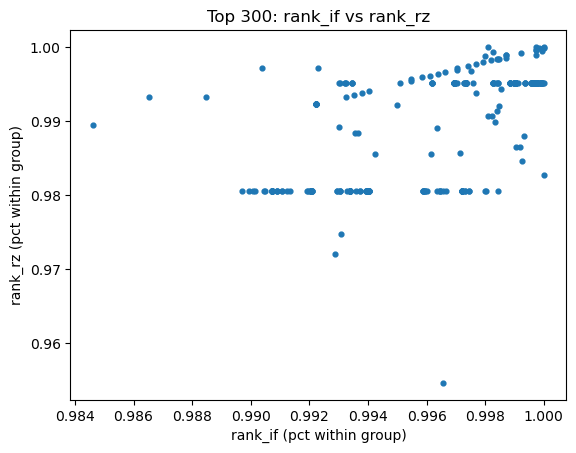

In [52]:
plt.figure()
plt.scatter(top["rank_if"], top["rank_rz"], s=12)
plt.xlabel("rank_if (pct within group)")
plt.ylabel("rank_rz (pct within group)")
plt.title(f"Top {topN}: rank_if vs rank_rz")
plt.show()